# Exercise 5: The Diffusion Equation — Implicit and Semi-Explicit Methods

## Learning Objectives

By completing this exercise, you will:
- Understand the CFL condition for parabolic (diffusive) PDEs
- Implement explicit, implicit, and semi-explicit time integration schemes
- Apply Newton-Raphson iteration for nonlinear implicit systems
- Compare computational efficiency of different methods
- (Optional) Implement Super-Time-Stepping (STS) acceleration

---

## Introduction

We now consider the viscous (diffusive) term from the full Burgers' equation:

$$\frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial x^2} \tag{1}$$

This is a **parabolic PDE**, which has very different stability properties compared to the hyperbolic advection equation.

---

## Part 1: Explicit Method

### Task 1.1: Derive the CFL Condition

**Question:** What is the CFL condition for eq. (1) when $\nu$ is:
1. A constant?
2. An array that depends on $x$?

### Task 1.2: Implement Explicit Diffusion

Solve equation (1) numerically with:

**Setup:**
- Domain: $x \in [-2.6, 2.6]$
- Periodic boundary conditions
- Initial condition:
$$u(x,t=t_0) = A\exp\left(-\frac{(x-x_c)^2}{W^2}\right) \tag{2}$$
- Parameters: $A = 0.3$, $W = 0.1$, $x_c = 0$, $\nu = 0.1$

**Implementation:** Fill in `step_diff_burgers` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_5.py).

> **Suggestion:** Apply forward derivative first, then backward derivative. Apply von Neumann analysis.

**Questions:**
1. Is it stable?
2. What is the time-step dependence on $\Delta x$?
3. How many steps are needed to reach $t = 1.8$ for `nump = 128`? And for `nump = 256`?

Using device: cpu
N = 128
dx     = 0.040625
dt     = 0.0037133789062499833
r      = 0.22499999999999898
nsteps = 485
T_used = 1.8009887695312419
----------------------------------------
N = 256
dx     = 0.0203125
dt     = 0.0009283447265625161
r      = 0.22500000000000392
nsteps = 1939
T_used = 1.8000604248047187
----------------------------------------


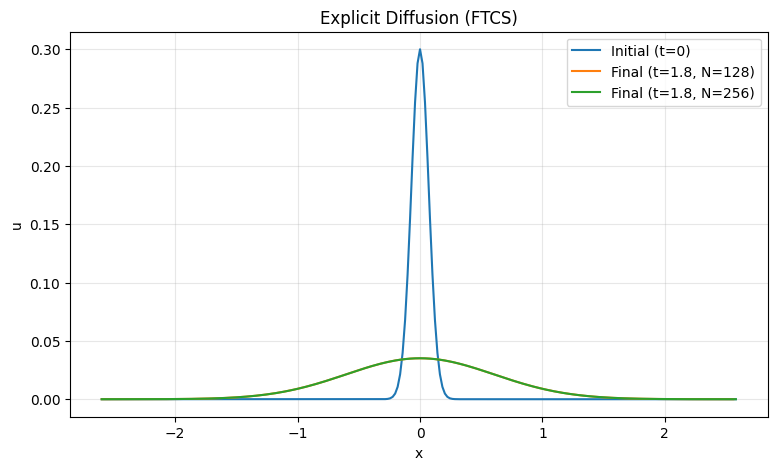

In [1]:
import torch
import matplotlib.pyplot as plt
import math
import importlib
import nm_lib.nm_ex.nm_lib_ex_5 as nm5
import numpy as np 
importlib.reload(nm5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
torch.set_default_dtype(dtype)

print("Using device:", device)
def explicit_diffusion_from_lib(x_t, u0_t, nu, t_end, cfl_cut=0.45):
    # torch to numpy
    x_np = x_t.detach().cpu().numpy()
    u0_np = u0_t.detach().cpu().numpy()

    # dt from the lib CFL
    dt = cfl_cut * nm5.cfl_diff_burger(nu, x_np)

    # choose number of explicit steps
    nsteps = int(round(t_end / dt))
    T_used = nsteps * dt

    t_np, unnt_np = nm5.evolv_diff_burgers(
        x_np, u0_np, nt=nsteps, a=nu, cfl_cut=cfl_cut, bnd_type="wrap"
    )

    u_final = torch.tensor(unnt_np[-1], dtype=u0_t.dtype, device=u0_t.device)
    return u_final, float(dt), int(nsteps), float(T_used)


def implicit_diffusion_from_lib(x_t, u0_t, nu, dt, nt, tol=1e-12, maxit=20):
    # torch to numpy
    x_np = x_t.detach().cpu().numpy()
    u0_np = u0_t.detach().cpu().numpy()

    # In the lib, nt counts the stored time levels, so nt+1 gives nt actual steps
    t_np, unnt_np, errt_np, countt_np = nm5.Newton_Raphson(
        x_np,
        u0_np,
        a=nu,
        dt=dt,
        nt=nt + 1,
        toll=tol,
        ncount=maxit,
        bnd_type="wrap",
        bnd_limits=[0, 1],
    )

    u_final = torch.tensor(unnt_np[:, -1], dtype=u0_t.dtype, device=u0_t.device)
    return u_final, t_np, errt_np, countt_np

# Exercise 5

#I will just call the diffusion equation same as the Heat Equation
# u_t = nu * u_xx

# Parameters
x0 = -2.6
xf =  2.6
A  = 0.3
W  = 0.1
xc = 0.0
v  = 0.1  

#Define the equation, intial 
def Heat_equation_intial(x):
    return A * torch.exp(-((x - xc) ** 2) / (W ** 2))

#The time
t0 = 0.0
t_end = 1.8

"""
# Explicit diffusion with periodic BC 
def step_diff_burgers_loop(u, dx, dt, v):
    r = v * dt / (dx ** 2)
    N = len(u)
    u_new = torch.empty_like(u)

    for i in range(1, N - 1):
        u_new[i] = u[i] + r * (u[i+1] - 2.0 * u[i] + u[i-1])

    # Periodic boundary
    u_new[0]  = u[0]  + r * (u[1]  - 2.0 * u[0]  + u[-1])
    u_new[-1] = u[-1] + r * (u[0]  - 2.0 * u[-1] + u[-2])

    return u_new

def solve_diffusion_explicit(num_slices, t_end=1.8, cfl=0.45, device=device):
    # periodic grid 
    x = torch.linspace(x0, xf, steps=num_slices + 1, device=device)[:-1]
    dx = (xf - x0) / num_slices

    dt = cfl * dx**2 / v
    dt_max = dx**2 / (2.0 * v) # stability limit for FTCS diffusion: dt <= dx^2/(2*nu)
    if dt > dt_max:
        raise ValueError(f"Unstable! dt={dt:.6e} > dt_max={dt_max:.6e}")

    u = Heat_equation_intial(x) # intial condition
    t = 0.0
    nsteps = 0
    r = v * dt / dx**2  

    while t < t_end - 1e-15:
        dt_step = min(dt, t_end - t)          # choose dt_step   
        r_step = v * dt_step / dx**2
        if r_step > 0.5:
            raise ValueError(f"Unstable: r_step={r_step:.6f} > 0.5")

        u = step_diff_burgers_loop(u, dx, dt_step, v) # one FTCS diffusion step
        t += dt_step # update time
        nsteps += 1

    return x, u, dx, dt, nsteps, r
"""

# Run explicit from the lib

N_list = [128, 256]
results = {}

for n in N_list:
    # periodic grid
    x = torch.linspace(x0, xf, steps=n + 1, device=device)[:-1]
    dx = (xf - x0) / n

    # intial condition
    u0 = Heat_equation_intial(x)

    # evolve with the lib
    u_final, dt, nsteps, T_used = explicit_diffusion_from_lib(
        x, u0, nu=v, t_end=t_end, cfl_cut=0.45
    )

    r = v * dt / dx**2
    results[n] = (x, u_final, dx, dt, nsteps, r, T_used)

    print(f"N = {n}")
    print(f"dx     = {dx}")
    print(f"dt     = {dt}")
    print(f"r      = {r}")
    print(f"nsteps = {nsteps}")
    print(f"T_used = {T_used}")
    print("-" * 40)

# Plot
x_plot = results[256][0]
u_init = Heat_equation_intial(x_plot)

plt.figure(figsize=(9, 5))
plt.plot(x_plot.cpu().numpy(), u_init.cpu().numpy(), label="Initial (t=0)")
plt.plot(results[128][0].cpu().numpy(), results[128][1].cpu().numpy(), label="Final (t=1.8, N=128)")
plt.plot(results[256][0].cpu().numpy(), results[256][1].cpu().numpy(), label="Final (t=1.8, N=256)")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Explicit Diffusion (FTCS)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# JMS 

<span style="color:green">Good.</span>


<span style="color:orange">Can you add a sentences addressing the results/conclusions/questions? I can see the numbers but I would like to see some reasoning.</span>

---

## Choose One of the Following Options:

---

## Option A: Implicit Methods (Newton-Raphson)

Implicit methods can relax the CFL constraint. See the [wiki: Implicit Methods](https://github.com/AST-Course/AST5110/wiki/Implicit-methods) for background.

### Task A.1: Implement the Newton-Rapson Method

The implicit scheme gives a nonlinear system $F(u^{n+1}) = 0$ where:

$$F_j = u^{n+1}_j - u^n_j - \nu \frac{\Delta t}{\Delta x^2}\left(u^{n+1}_{j+1} - 2u^{n+1}_{j} + u^{n+1}_{j-1}\right)$$

**Implementation:** Fill in `NR_f` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_5.py).

### Task A.2: Implement the Jacobian

The Jacobian matrix elements are:

$$J_{jk} = \frac{\partial F_j}{\partial u^{n+1}_k}$$

**Implementation:** Fill in `jacobian` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_5.py).

> **Note:** This matrix is linear in $u$ (tridiagonal structure).

### Task A.3: Validate and Benchmark

1. Test the model against [self-similar solutions](https://github.com/AST-Course/AST5110/wiki/Self-similar-solution-for-parabolic-eq)
2. Compare timing with the Lax method using `time.time`
3. Use: `nump = 256`, `nt = 30`, `dt = 0.1`

### Task A.4: Nonlinear Diffusion (Advanced)

Consider a nonlinear diffusion where $\nu$ depends on $u$:

$$\frac{\partial u}{\partial t} = u \frac{\partial^2 u}{\partial x^2}$$

**Implementation:** Fill in `Newton_Raphson_u`, `jacobian_u`, and `NR_f_u`.

**Parameters:** Error tolerance = $10^{-14}$, increase `ncount` to 1000 if needed.

**Questions:**
1. How many iterations does the method need to converge?
2. Why is this different from the linear case?

Newton iterations per step (first 10): [20. 20. 20. 20. 20. 20. 20. 20. 20. 20.]
Max Newton iteration used: 20
max error = 0.0003434114649998425
L2  error = 0.00015320952190331754


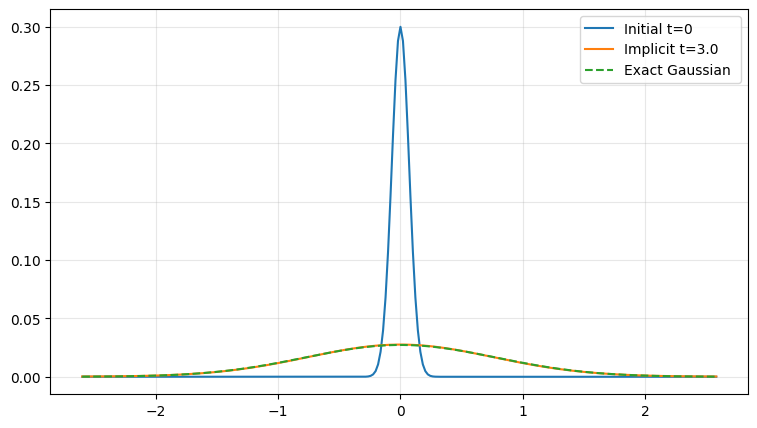

Effect of increasing dt in the implicit linear diffusion scheme
------------------------------------------------------------------------------------------
dt =  0.050 | nt =  36 | max Newton iter = 50 | max error = 3.658e-04 | L2 error = 1.399e-04
dt =  0.100 | nt =  18 | max Newton iter = 50 | max error = 7.366e-04 | L2 error = 2.781e-04
dt =  0.200 | nt =   9 | max Newton iter = 50 | max error = 1.509e-03 | L2 error = 5.546e-04
dt =  0.400 | nt =   4 | max Newton iter = 50 | max error = 3.837e-03 | L2 error = 1.277e-03


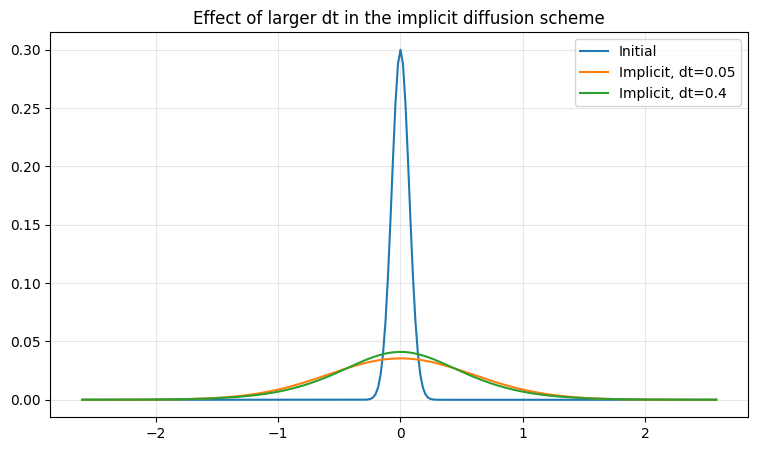

Effect of the Newton tolerance in the implicit linear diffusion scheme
------------------------------------------------------------------------------------------
tol = 1e-06 | avg Newton iter =  44.67 | max Newton iter = 50 | last recorded error = 5.432e-03
tol = 1e-08 | avg Newton iter =  50.00 | max Newton iter = 50 | last recorded error = 5.710e-03
tol = 1e-10 | avg Newton iter =  50.00 | max Newton iter = 50 | last recorded error = 5.713e-03
tol = 1e-12 | avg Newton iter =  50.00 | max Newton iter = 50 | last recorded error = 5.713e-03
tol = 1e-14 | avg Newton iter =  50.00 | max Newton iter = 50 | last recorded error = 5.713e-03
Nonlinear implicit diffusion test
------------------------------------------------------------
Newton iterations per step (first 10): [6. 5. 5. 5. 5. 5. 5. 5. 4. 5.]
Average Newton iterations: 4.433333333333334
Max Newton iterations: 6
Last recorded error: 2.170801395308562e-16


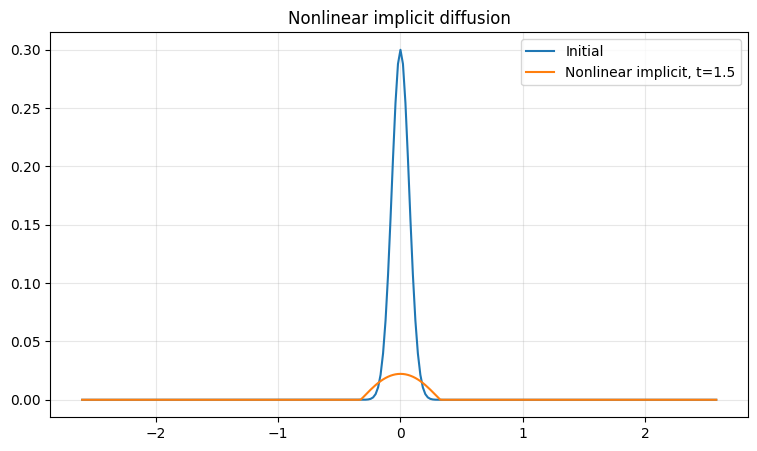

In [2]:


# I choose the part A
"""
#Task A1

# F_j = u_new[j] - u_old[j] - r*(u_new[j+1]-2u_new[j]+u_new[j-1])
# periodic BC 
def NR_f_loop(u_new, u_old, r):
    N = u_new.numel()
    F = torch.empty_like(u_new)
    for j in range(N):
        jp = (j + 1) % N
        jm = (j - 1) % N
        lap = u_new[jp] - 2.0 * u_new[j] + u_new[jm]
        F[j] = u_new[j] - u_old[j] - r * lap
    return F


# Task A2
# J[j,j] = 1+2r
# J[j,j+1] = -r, J[j,j-1] = -r
# Task A1 Residual F(u_new)
def NR_f_loop(u_new, u_old, r):
    N = u_new.numel()
    F = torch.empty_like(u_new)
    for j in range(N):
        jp = (j + 1) % N
        jm = (j - 1) % N
        lap = u_new[jp] - 2.0 * u_new[j] + u_new[jm]
        F[j] = u_new[j] - u_old[j] - r * lap
    return F

# Task A2 Jacobian J
def jacobian_loop(N, r, device, dtype):
    J = torch.zeros((N, N), device=device, dtype=dtype)
    for j in range(N):
        J[j, j] = 1.0 + 2.0 * r
        J[j, (j + 1) % N] = -r
        J[j, (j - 1) % N] = -r
    return J
def Newton_Raphson(u_old, dx, dt, nu, tol=1e-12, maxit=20):
    # using Newton iterations

    r = nu * dt / (dx**2)
    N = u_old.numel()


    u_new = u_old.clone()


    J = jacobian_loop(N, r, device=u_old.device, dtype=u_old.dtype)

    for it in range(1, maxit+1):
        F = NR_f_loop(u_new, u_old, r)

        # stopping rule: infinity norm of residual
        if torch.max(torch.abs(F)).item() < tol:
            return u_new, it

        # Newton update: J * delta = -F
        delta = torch.linalg.solve(J, -F)
        u_new = u_new + delta

    # if not converged
    return u_new, maxit
def solve_implicit(u0, x0, xf, nt=30, dt=0.1, nu=0.1, tol=1e-12):
    N = u0.numel()
    dx = (xf - x0) / N
    u = u0.clone()
    iters = []
    for _ in range(nt):
        u, it = Newton_Raphson(u, dx, dt, nu, tol=tol, maxit=20)
        iters.append(it)
    return u, dx, iters

# Task A3: Validate and Benchmark

#Parameter.
nump = 256
nt = 30
dt = 0.1
nu = 0.1

def solve_implicit(u0, x0, xf, nt=30, dt=0.1, nu=0.1, tol=1e-12):
    N = u0.numel()
    dx = (xf - x0) / N
    u = u0.clone()
    iters = []

    for _ in range(nt):
        u, it = Newton_Raphson(u, dx, dt, nu, tol=tol, maxit=20)
        iters.append(it)

    print("Newton iterations per step (first 10):", iters[:10])
    print("Max Newton iteration used:", max(iters))

    return u, dx, iters

#  Analytical solution check for Gaussian initial condition.
# If u(x,0) = A exp(-(x-xc)^2/W^2), then for u_t = nu u_xx on R:
# u(x,t) = A * W/sqrt(W^2 + 4 nu t) * exp(-(x-xc)^2/(W^2 + 4 nu t))
"""

def exact_gaussian_heat(x, t, A=0.3, W=0.1, xc=0.0, nu=0.1):
    denom = W*W + 4.0*nu*t
    amp = A * W / math.sqrt(denom)
    u = torch.empty_like(x)
    for i in range(x.numel()):
        u[i] = amp * torch.exp(-((x[i]-xc)**2)/denom)
    return u


# initial condition
nump = 256
nt = 30
dt = 0.1
nu = 0.1

# grid
x = torch.linspace(x0, xf, steps=nump + 1, device=device)[:-1]
u0 = A * torch.exp(-((x - xc)**2) / (W**2))

# run implicit solver from the lib
u_num, t_np, errt_np, countt_np = implicit_diffusion_from_lib(
    x, u0, nu=nu, dt=dt, nt=nt, tol=1e-12, maxit=20
)

print("Newton iterations per step (first 10):", countt_np[1:11])
print("Max Newton iteration used:", int(np.max(countt_np)))

t_final = nt * dt
u_ex = exact_gaussian_heat(x, t_final, A=A, W=W, xc=xc, nu=nu)

max_err = float(torch.max(torch.abs(u_num - u_ex)).cpu())
l2_err  = float(torch.sqrt(torch.mean((u_num - u_ex)**2)).cpu())
print("max error =", max_err)
print("L2  error =", l2_err)

#  plot
plt.figure(figsize=(9,5))
plt.plot(x.cpu().numpy(), u0.cpu().numpy(), label="Initial t=0")
plt.plot(x.cpu().numpy(), u_num.cpu().numpy(), label=f"Implicit t={t_final}")
plt.plot(x.cpu().numpy(), u_ex.cpu().numpy(), "--", label="Exact Gaussian ")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


def implicit_nonlinear_diffusion_from_lib(x_t, u0_t, dt, nt, tol=1e-12, maxit=50):
    x_np = x_t.detach().cpu().numpy()
    u0_np = u0_t.detach().cpu().numpy()

    t_np, unnt_np, errt_np, countt_np = nm5.Newton_Raphson_u(
        x_np,
        u0_np,
        dt=dt,
        nt=nt + 1,
        toll=tol,
        ncount=maxit,
        bnd_type="wrap",
        bnd_limits=[0, 1],
    )

    u_final = torch.tensor(unnt_np[:, -1], dtype=u0_t.dtype, device=u0_t.device)
    return u_final, t_np, errt_np, countt_np


#  What happens if dt is larger in the implicit scheme?

dt_list = [0.05, 0.1, 0.2, 0.4]

print("Effect of increasing dt in the implicit linear diffusion scheme")
print("-" * 90)

for dt_test in dt_list:
    nt_test = int(round(t_end / dt_test))
    t_final_test = nt_test * dt_test

    u_num_dt, t_np_dt, errt_np_dt, countt_np_dt = implicit_diffusion_from_lib(
        x, u0, nu=nu, dt=dt_test, nt=nt_test, tol=1e-12, maxit=50
    )

    u_ex_dt = exact_gaussian_heat(x, t_final_test, A=A, W=W, xc=xc, nu=nu)

    max_err_dt = float(torch.max(torch.abs(u_num_dt - u_ex_dt)).cpu())
    l2_err_dt  = float(torch.sqrt(torch.mean((u_num_dt - u_ex_dt) ** 2)).cpu())

    print(
        f"dt = {dt_test:6.3f} | nt = {nt_test:3d} | "
        f"max Newton iter = {int(np.max(countt_np_dt)):2d} | "
        f"max error = {max_err_dt:.3e} | L2 error = {l2_err_dt:.3e}"
    )

# plot the small dt vs large dt
dt_small = 0.05
nt_small = int(round(t_end / dt_small))
u_small, _, _, _ = implicit_diffusion_from_lib(
    x, u0, nu=nu, dt=dt_small, nt=nt_small, tol=1e-12, maxit=50
)

dt_large = 0.4
nt_large = int(round(t_end / dt_large))
u_large, _, _, _ = implicit_diffusion_from_lib(
    x, u0, nu=nu, dt=dt_large, nt=nt_large, tol=1e-12, maxit=50
)

plt.figure(figsize=(9,5))
plt.plot(x.cpu().numpy(), u0.cpu().numpy(), label="Initial")
plt.plot(x.cpu().numpy(), u_small.cpu().numpy(), label=f"Implicit, dt={dt_small}")
plt.plot(x.cpu().numpy(), u_large.cpu().numpy(), label=f"Implicit, dt={dt_large}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Effect of larger dt in the implicit diffusion scheme")
plt.show()

#  What happens if the tolerance is too strict?


tol_list = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14]
dt_tol = 0.1
nt_tol = int(round(t_end / dt_tol))

print("Effect of the Newton tolerance in the implicit linear diffusion scheme")
print("-" * 90)

for tol_test in tol_list:
    u_tol, t_np_tol, errt_np_tol, countt_np_tol = implicit_diffusion_from_lib(
        x, u0, nu=nu, dt=dt_tol, nt=nt_tol, tol=tol_test, maxit=50
    )

    used_counts = countt_np_tol[1:]
    avg_it = float(np.mean(used_counts))
    max_it = int(np.max(used_counts))
    last_err = float(errt_np_tol[-1])

    print(
        f"tol = {tol_test:.0e} | avg Newton iter = {avg_it:6.2f} | "
        f"max Newton iter = {max_it:2d} | last recorded error = {last_err:.3e}"
    )


# Nonlinear diffusion


dt_nl = 0.05
nt_nl = 30
tol_nl = 1e-10
maxit_nl = 100

u_nl, t_np_nl, errt_np_nl, countt_np_nl = implicit_nonlinear_diffusion_from_lib(
    x, u0, dt=dt_nl, nt=nt_nl, tol=tol_nl, maxit=maxit_nl
)

print("Nonlinear implicit diffusion test")
print("-" * 60)
print("Newton iterations per step (first 10):", countt_np_nl[1:11])
print("Average Newton iterations:", float(np.mean(countt_np_nl[1:])))
print("Max Newton iterations:", int(np.max(countt_np_nl)))
print("Last recorded error:", float(errt_np_nl[-1]))

plt.figure(figsize=(9,5))
plt.plot(x.cpu().numpy(), u0.cpu().numpy(), label="Initial")
plt.plot(x.cpu().numpy(), u_nl.cpu().numpy(), label=f"Nonlinear implicit, t={dt_nl * nt_nl}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Nonlinear implicit diffusion")
plt.show()

# JMS 

<span style="color:green">Very nice!</span>

---

## Option B: Super-Time-Stepping (STS)

Super-Time-Stepping (STS) is an acceleration technique for parabolic terms. It performs a sequence of "unstable" intermediate steps, but the overall cycle is stable. See the [wiki: Super-Time-Stepping](https://github.com/AST-Course/AST5110/wiki/Super-time-stepping) for details.

### Task B.1: Implement STS

**Implementation:** Fill in `evol_sts` and `taui_sts` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_5.py).

### Task B.2: Analyze STS Behavior

1. Visualize how `taui_sts` varies with $\nu$ and `niter`
2. Compare the solution with the analytical one for:
   - Final STS step
   - Intermediate STS steps
3. For full STS cycles, how does the solution improve with $\nu$? With `niter`?


### Task B.3: Error Analysis

**Questions:**
1. Is there a relationship between the error and the parameters $\nu$ and `niter`?
2. For which values of `niter` and $\nu$ does STS provide larger effective time steps than ordinary explicit methods?

---

## Hints

<details>
<summary><b>Hint 1: CFL condition for diffusion</b></summary>

For explicit diffusion with centered second derivative:
$$\Delta t \leq \frac{(\Delta x)^2}{2\nu}$$

Note the **quadratic** dependence on $\Delta x$ — this is much more restrictive than hyperbolic equations!
</details>

<details>
<summary><b>Hint 2: Jacobian structure</b></summary>

For the linear diffusion equation, the Jacobian is tridiagonal:
- Diagonal: $1 + 2\nu \Delta t / \Delta x^2$
- Off-diagonal: $-\nu \Delta t / \Delta x^2$

Use sparse matrix operations for efficiency.
</details>

<details>
<summary><b>Hint 3: Newton-Raphson convergence</b></summary>

For linear problems, Newton-Raphson converges in one iteration. For nonlinear problems, expect multiple iterations. Monitor the residual norm to track convergence.
</details>

In [4]:
#Explicit

# FTCS is stable if r = nu*dt/dx^2 <= 0.5.

# Here I did not choose r directly.
# I chose cfl_cut = 0.45 first, and then dt from the CFL formula.
# So the resulting value is r = 0.225, which is inside the stable range.

#Implicit

# Implicit diffusion gives a linear system at each time step.

# I use the Gaussian heat formula as a reference solution.

# The final numerical error is small, so the implicit solution looks correct.

# But the Newton solver still reaches the maximum number of iterations at every step.

# For this linear problem, Newton's method should normally be very fast.
# So if it always hits the iteration limit, then the reason is probably not only the tolerance.
# It is more likely that the stopping rule or some part of the implementation is not ideal.

# If dt is larger in the implicit scheme, the method is still stable,
# but the solution becomes less accurate and more diffusive.

# This also matches the plots:
# larger dt gives a smoother and more smeared solution.

# If the tolerance is made extremely strict, the iteration count becomes larger,
# but the final accuracy does not improve much in this linear test.

# If the problem is nonlinear, then each implicit step requires solving a real nonlinear system.
# In that case, several Newton iterations are normal,
# because the Jacobian depends on the current iterate.

# So the nonlinear case is harder than the present linear case.

# JMS 

<span style="color:green">Good job addressing my previous comments. </span>

<span style="color:green">About the first part that reaches the maximum number of iterations is most likely due to the strick tollerance. Your argument is correct, linear problems are ideal for this implicit methods and typically with this scheme a couple of iterations does the job. Also all the other description looks great! good job. </span>